<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_12_NLMeans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from skimage.io import imread
import numpy as np
from scipy.io import loadmat
from matplotlib import pyplot as plt
import time
from google.colab import drive         # pyright: ignore[reportMissingImports]

In [ ]:
rootfolder = '.'

In [4]:
drive.mount('/content/drive', force_remount=True)
ROOT_FOLDER = '/content/drive/MyDrive/MMIP/data'

Mounted at /content/drive


Load the image and rescale it in $[0,1]$

In [5]:
img = imread(f'{ROOT_FOLDER}/cameraman.png') / 255
img = img[50:200, 50:200]
imsz = img.shape

# patch size
p = 7

# number of elements in the patch
M = p ** 2

# radius of the search neighborhood
H = 12

Corrupt the image with white gaussian noise

In [ ]:
sigma_noise = 20/255
noisy_img = img + np.random.normal(0, sigma_noise, size=imsz)

Compute the PSNR of the noisy input

In [9]:
psnr_noisy = np.log(1/np.mean(np.square(img - noisy_img)))

Text(0.5, 1.0, 'Noisy image, PSNR = 5.07')

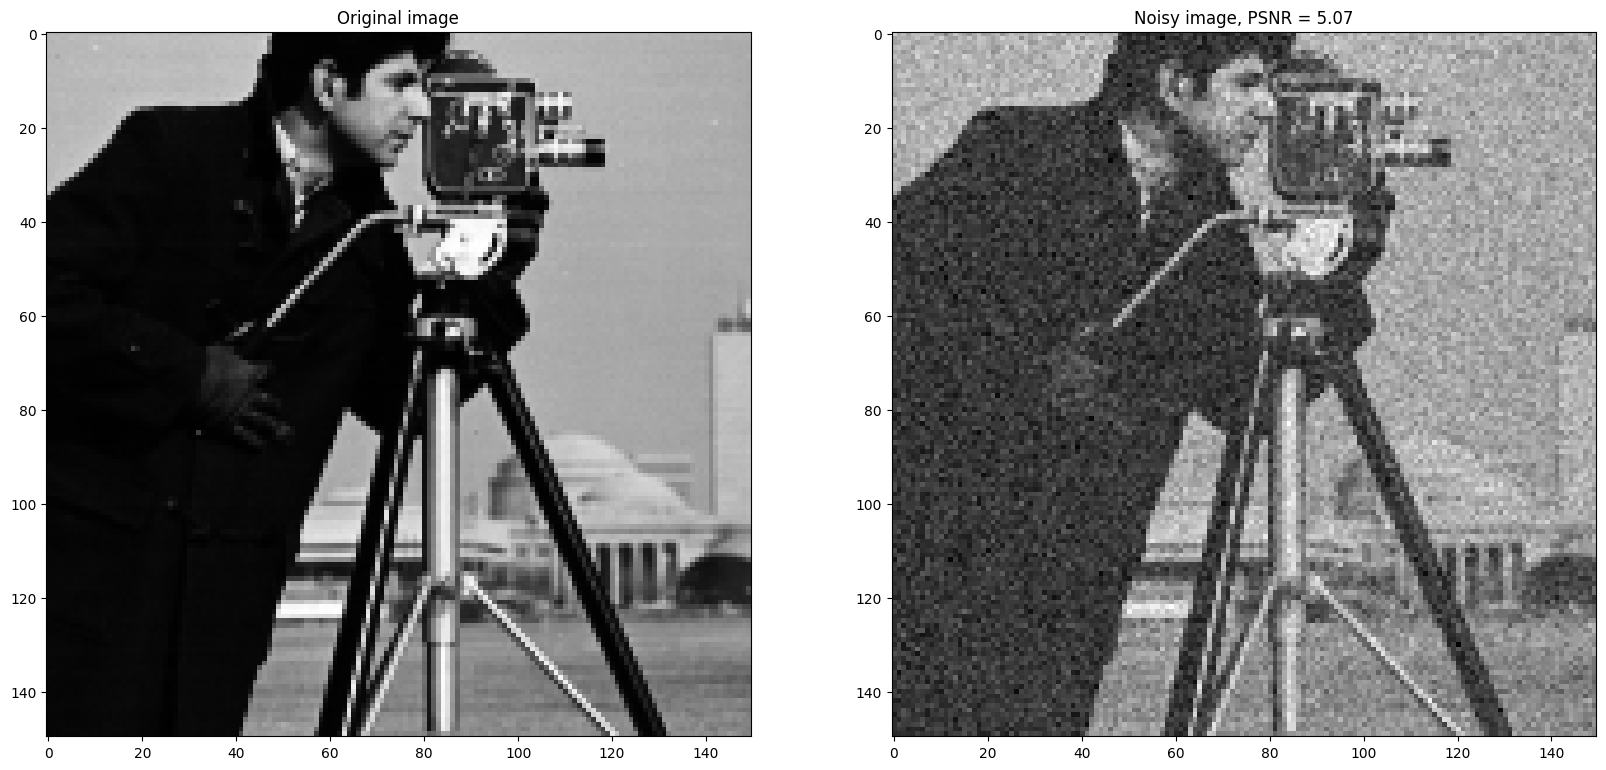

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(20, 10))
ax[0].imshow(img, cmap='gray')
ax[0].set_title('Original image')

ax[1].imshow(noisy_img, cmap='gray')
ax[1].set_title(f'Noisy image, PSNR = {psnr_noisy:.2f}')

Pixel-based NL-Means
--------------------
Set parameters and initialize the variables

In [18]:
# initialize the estimated image
img_hat = np.zeros_like(img)

# pad the noisy image
k = p // 2
img_pad = np.pad(noisy_img, H + k, mode='symmetric')

Main loop

In [ ]:
for r in range(0, imsz[0]):
    for c in range(0, imsz[1]):
        # extrach the patch from img_pad whose center has the location (r, c) in the noisy image
        s = img_pad[r:r+p, c:c+p]

        # initialize the pixel estimate and the total weights
        pixel_hat = 0
        weight = np.zeros((2*M + 1, 2*M + 1))

        # extract all the patches in the search neighborhood
        for i in range(-H, H+1):
            for j in range(-H, H+1):
                # extract the patch
                if (0 <= r+k+i <= imsz[0] - 1 and 0 <= c+k+j <= imsz[1] - 1):
                    z = img_pad[r+k:r + k + i, c+k:c+k+j]

                    # compute the distance with the reference patch
                    d = np.linalg.norm(s - z) ** 2
                    # update the weight and the pixel estimate
                    weight[i + H, j + H] += np.exp(-d/(sigma_noise ** 2 * M))
                    pixel_hat += weight[i + H, j + H] * z[p // 2, p//2]

        # estimate the pixel (i, j) as the weighted average of the central pixel of the extracted patches
        img_hat[i, j] = pixel_hat/weight

ValueError: operands could not be broadcast together with shapes (7,19) (0,0) 

In [ ]:
d = np.norm(s - z) ** 2

AttributeError: module 'numpy' has no attribute 'norm'

Compute the PSNR of the estimated image

In [ ]:
# psnr_hat =
plt.figure(figsize=(10, 10))
plt.imshow(img_hat, cmap='gray')
plt.title(f'Estimated Image,\nPSNR = {psnr_hat:.2f}')